# 1. Project Overview 

# E-Commerce Customer Behavior Analysis

## Project Overview

E-commerce businesses collect large amounts of transaction data, but the real
value comes from understanding how customers purchase, how orders are fulfilled,
and what factors are associated with customer satisfaction.

This project explores e-commerce order data to understand:

- How order activity changes over time
- How customers prefer to pay
- How long orders take to arrive
- Whether delivery performance affects customer satisfaction
- Which operational patterns may require business attention

The project focuses on descriptive analytics, visualisation and statistical
testing. Predictive modelling will be explored separately in Part 2.

# 2. Import Libraries 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

# 3. Load Data 

In [9]:
df = pd.read_csv("orders.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,price,freight,payment,installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,38.71,1.0,credit_card,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,179.12,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,72.20,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,28.62,1.0,credit_card,5.0


# 4. Basic Analysis 

In [12]:
print("Dataset shape:", df.shape)

Dataset shape: (99441, 15)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   n_items                        98666 non-null  float64
 9   price                          98666 non-null  float64
 10  freight                        98666 non-null  float64
 11  payment                        99440 non-null  float64
 12  installments                   99440 non-null 

In [16]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,98875,2018-04-11 10:48:14,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,99281,90733,2018-02-27 04:31:10,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,96476,95664,2018-05-08 23:38:46,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_items,98666.0,NaN,NaN,NaN,1.141731,0.538452,1.0,1.0,1.0,1.0,21.0
price,98666.0,NaN,NaN,NaN,137.754076,210.645145,0.85,45.9,86.9,149.9,13440.0


In [18]:
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])

Number of rows: 99441
Number of columns: 15


Interpretaion here :

# 5. Data Cleaning 

In [32]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate order IDs:", df["order_id"].duplicated().sum())

Duplicate rows: 0
Duplicate order IDs: 0


In [34]:
missing_summary = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Missing_Percent": df.isnull().mean() * 100
})

missing_summary = (
    missing_summary[
        missing_summary["Missing"] > 0
    ]
    .sort_values("Missing_Percent", ascending=False)
)

missing_summary.round(2)

,Missing,Missing_Percent
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
n_items,775,0.78
price,775,0.78
freight,775,0.78
review_score,768,0.77
order_approved_at,160,0.16
payment,1,0.00
installments,1,0.00
payment_type,1,0.00


In [36]:
df.loc[
    df["order_delivered_customer_date"].isnull(),
    "order_status"
].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

# 6.Date Conversion & Feature Engineering

In [39]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

In [41]:
df[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

# 5.2 Purchase date features

In [46]:
df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

df["purchase_day"] = (
    df["order_purchase_timestamp"]
    .dt.day_name()
)

df["purchase_hour"] = (
    df["order_purchase_timestamp"]
    .dt.hour
)

In [48]:
df["approval_hours"] = (
    df["order_approved_at"]
    - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

In [50]:
print(
    "Negative approval times:",
    (df["approval_hours"] < 0).sum()
)

Negative approval times: 0


# 7. Creating Delivered Orders Dataset

In [63]:
# Remove rows with missing delivery timestamps
delivered_orders = delivered_orders.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
).copy()


# Calculate actual delivery time in days
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)


# Determine whether delivery was late
delivered_orders["was_late"] = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
)


# Convert True/False into readable labels
delivered_orders["delivery_status"] = np.where(
    delivered_orders["was_late"],
    "Late",
    "On Time"
)


# Check that the new columns exist
print(
    delivered_orders[
        [
            "delivery_days",
            "was_late",
            "delivery_status",
            "review_score"
        ]
    ].head()
)

   delivery_days  was_late delivery_status  review_score
0       8.436574     False         On Time           4.0
1      13.782037     False         On Time           4.0
2       9.394213     False         On Time           5.0
3      13.208750     False         On Time           5.0
4       2.873877     False         On Time           5.0


# 8. Handling Outliers 

In [66]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [68]:
lower_bound, upper_bound = iqr_bounds(
    delivered_orders["delivery_days"].dropna()
)

print(
    f"Normal delivery range using IQR: "
    f"{lower_bound:.2f} to {upper_bound:.2f} days"
)

Normal delivery range using IQR: -6.66 to 29.15 days


In [70]:
delivered_orders["delivery_outlier"] = ~(
    delivered_orders["delivery_days"]
    .between(
        lower_bound,
        upper_bound
    )
)

In [72]:
print(
    "Delivery outliers:",
    delivered_orders["delivery_outlier"].sum()
)

print(
    "Outlier percentage:",
    f"{delivered_orders['delivery_outlier'].mean() * 100:.2f}%"
)

Delivery outliers: 4896
Outlier percentage: 5.08%


### Outlier Treatment

Extreme delivery times are flagged rather than automatically removed.

Some may represent genuine service failures rather than incorrect data, so
they are only excluded where extreme values would make a visualisation
difficult to interpret.

# 9. KPI Summary 

In [76]:
total_orders = df["order_id"].nunique()

delivered_count = (
    df["order_status"]
    .eq("delivered")
    .sum()
)

delivery_rate = (
    delivered_count / total_orders
) * 100

average_payment = df["payment"].mean()

average_review = df["review_score"].mean()

average_delivery_days = (
    delivered_orders["delivery_days"].mean()
)

late_delivery_rate = (
    delivered_orders["was_late"].mean()
) * 100

In [79]:
print(f"Total Orders: {total_orders:,}")
print(f"Delivered Orders: {delivered_count:,}")
print(f"Delivery Rate: {delivery_rate:.2f}%")
print(f"Average Payment: {average_payment:.2f}")
print(f"Average Review Score: {average_review:.2f}")
print(f"Average Delivery Time: {average_delivery_days:.2f} days")
print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")

Total Orders: 99,441
Delivered Orders: 96,478
Delivery Rate: 97.02%
Average Payment: 160.99
Average Review Score: 4.09
Average Delivery Time: 12.56 days
Late Delivery Rate: 8.11%


# 10. Order Behaviour Analysis 

## 10.1 Monthly Order Trend 

In [83]:
monthly_orders = (
    df
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

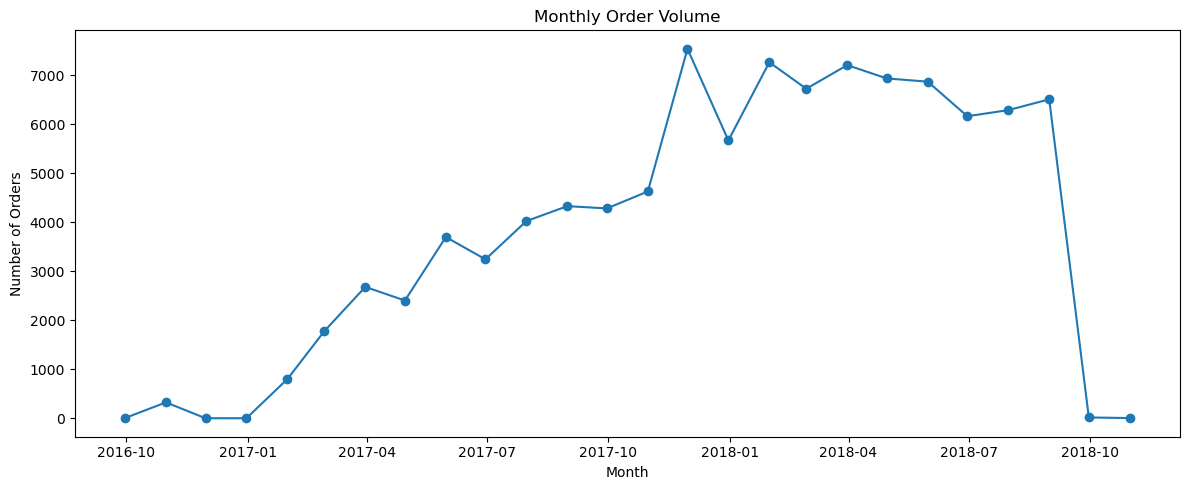

In [85]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [87]:
# Finding Peak Month 

peak_month = monthly_orders.idxmax()
peak_orders = monthly_orders.max()

print(
    f"Highest order volume: "
    f"{peak_orders:,} orders in "
    f"{peak_month.strftime('%B %Y')}"
)

Highest order volume: 7,544 orders in November 2017


## 10.2 Orders by Day of Week 

In [92]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

orders_by_day = (
    df["purchase_day"]
    .value_counts()
    .reindex(day_order)
)

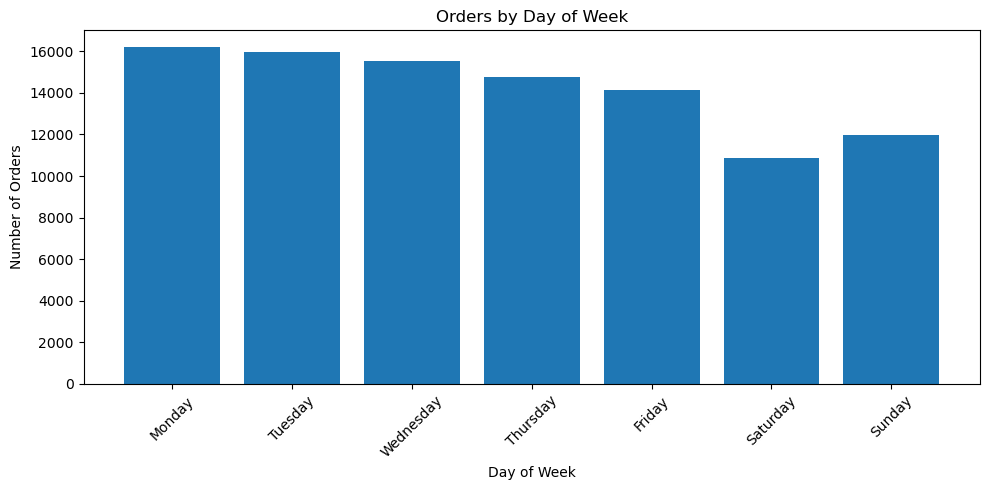

In [94]:
plt.figure(figsize=(10, 5))

plt.bar(
    orders_by_day.index,
    orders_by_day.values
)

plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [98]:
# Busiest day 

print(
    "Busiest day:", 
    orders_by_day.idxmax()
)

Busiest day: Monday


## 10.3 Orders by Hour 

In [101]:
orders_by_hour = (
    df["purchase_hour"]
    .value_counts()
    .sort_index()
)

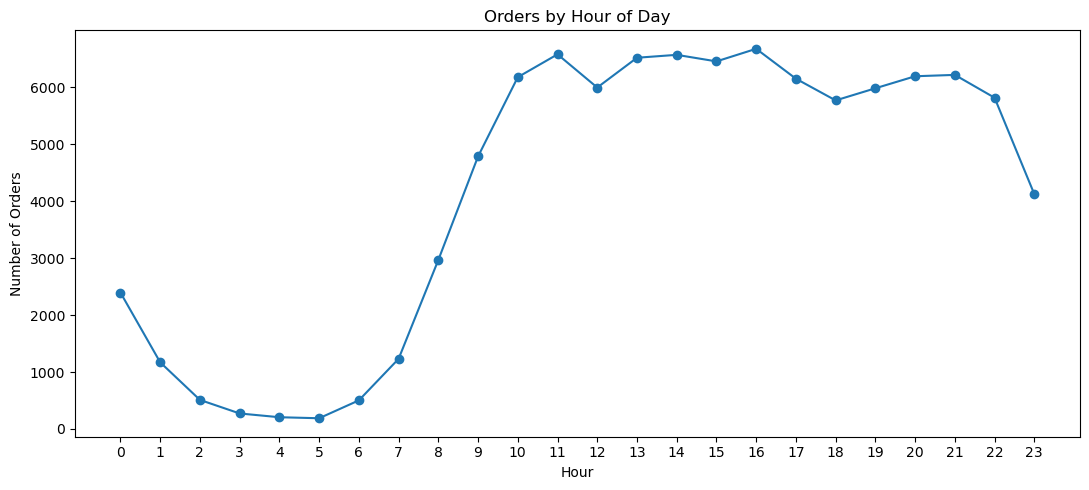

In [103]:
plt.figure(figsize=(11, 5))

plt.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker="o"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [105]:
#Peak Hour 

print(
    "Peak purchase hour:"
    f"{orders_by_hour.idxmax()}:00"
)

Peak purchase hour:16:00


## Observations :  

 Order activity shows clear patterns across time, day of week, and hour of day.

- Monthly order volume increased strongly from early 2017 and remained relatively high through most of 2018, with the highest activity occurring around the end of 2017 and early 2018. The sharp drop at the end of the timeline is likely caused by the dataset ending, so those final months should be treated as partial periods rather than a real collapse in demand.

- Orders are highest at the beginning of the week, with Monday and Tuesday recording the most activity, while Saturday is the quietest day. This suggests that customer purchasing is generally stronger during weekdays than weekends.

- Hourly activity is lowest during the early morning hours and rises sharply from around 08:00 onward. Orders remain consistently high from late morning through the evening, with the strongest activity occurring around the afternoon period. Overall, customers appear most active during normal daytime and early-evening hours

# 11. Cart Size 

In [114]:
item_summary = (
    df["n_items"]
    .value_counts()
    .sort_index()
)

item_summary.head(10)

n_items
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
Name: count, dtype: int64

In [116]:
single_item_percentage = (
    (df["n_items"] == 1).mean() * 100
)

print(
    f"Single-item orders: "
    f"{single_item_percentage:.2f}%"
)

Single-item orders: 89.36%


In [118]:
item_plot = item_summary[
    item_summary.index <= 10
]

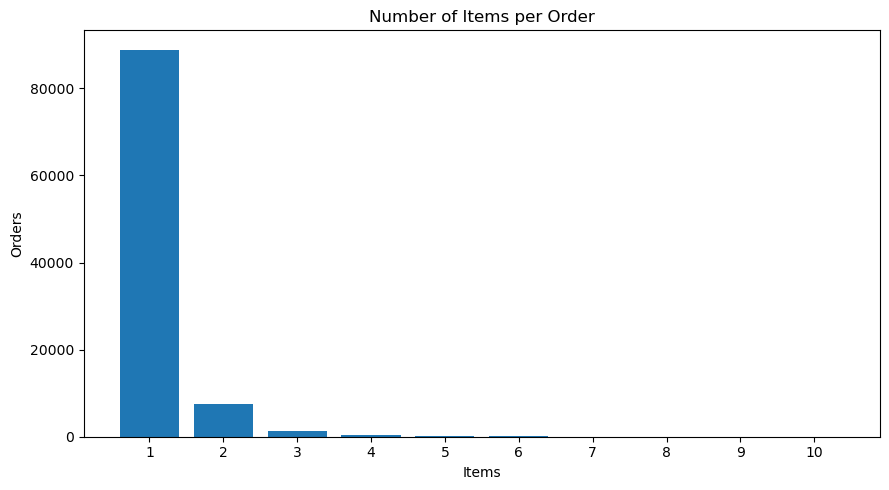

In [120]:
plt.figure(figsize=(9, 5))

plt.bar(
    item_plot.index.astype(int).astype(str),
    item_plot.values
)

plt.title("Number of Items per Order")
plt.xlabel("Items")
plt.ylabel("Orders")

plt.tight_layout()
plt.show()

## Observation :

Most purchases contain relatively few products, with single-item orders
representing the typical basket size.

# 12. Payment Behaviour 

In [125]:
payment_summary = (
    df
    .groupby("payment_type")
    .agg(
        orders=("order_id", "count"),
        avg_payment=("payment", "mean"),
        avg_installments=("installments", "mean"),
        avg_review=("review_score", "mean")
    )
    .sort_values(
        "orders",
        ascending=False
    )
)

payment_summary.round(2)

,orders,avg_payment,avg_installments,avg_review
payment_type,,,,
credit_card,75387,166.63,3.53,4.09
boleto,19784,145.03,1.00,4.09
voucher,2739,131.28,1.46,4.01
debit_card,1527,142.72,1.00,4.17
not_defined,3,0.00,1.00,1.67


In [127]:
payment_summary["order_share"] = (
    payment_summary["orders"]
    / payment_summary["orders"].sum()
    * 100
)

payment_summary.round(2)

,orders,avg_payment,avg_installments,avg_review,order_share
payment_type,,,,,
credit_card,75387,166.63,3.53,4.09,75.81
boleto,19784,145.03,1.00,4.09,19.90
voucher,2739,131.28,1.46,4.01,2.75
debit_card,1527,142.72,1.00,4.17,1.54
not_defined,3,0.00,1.00,1.67,0.00


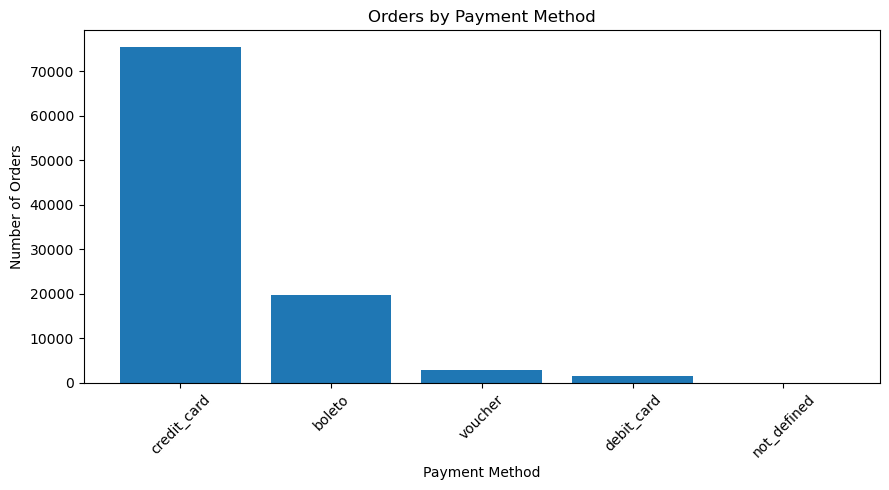

In [129]:
plt.figure(figsize=(9, 5))

plt.bar(
    payment_summary.index,
    payment_summary["orders"]
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Observation

Credit cards are the most frequently used payment method, accounting for the
majority of transactions.

Review scores remain relatively similar across the main payment methods,
suggesting that payment type itself may not be a major driver of customer
satisfaction.

# 13. Customer Satisfaction 

In [133]:
review_counts = (
    df["review_score"]
    .value_counts()
    .sort_index()
)

review_counts

review_score
1.000000    11316
1.500000        8
2.000000     3125
2.500000       34
3.000000     8136
3.333333        1
3.500000       25
4.000000    19018
4.333333        1
4.500000       54
5.000000    56955
Name: count, dtype: int64

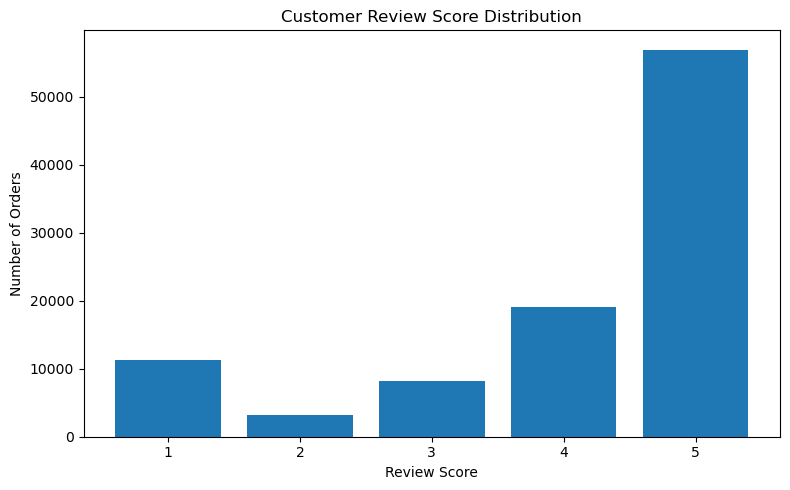

In [135]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_counts.index.astype(int).astype(str),
    review_counts.values
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [137]:
positive_review_rate = (
    df["review_score"]
    .isin([4, 5])
    .mean()
    * 100
)

print(
    f"Reviews rated 4 or 5 stars: "
    f"{positive_review_rate:.2f}%"
)

Reviews rated 4 or 5 stars: 76.40%


# 14. Delivery Time vs Customer Satisfaction 

In [140]:
clean_delivered = delivered_orders[
    ~delivered_orders["delivery_outlier"]
].copy()

In [142]:
clean_delivered["delivery_group"] = pd.cut(
    clean_delivered["delivery_days"],
    bins=[
        0,
        5,
        10,
        15,
        20,
        30,
        np.inf
    ],
    labels=[
        "0-5 days",
        "5-10 days",
        "10-15 days",
        "15-20 days",
        "20-30 days",
        "30+ days"
    ]
)

In [144]:
delivery_review_summary = (
    clean_delivered
    .groupby(
        "delivery_group",
        observed=True
    )
    .agg(
        avg_review=("review_score", "mean"),
        orders=("order_id", "count")
    )
)

delivery_review_summary.round(2)

,avg_review,orders
delivery_group,,
0-5 days,4.45,13430
5-10 days,4.36,33050
10-15 days,4.27,23613
15-20 days,4.13,12154
20-30 days,3.71,9327


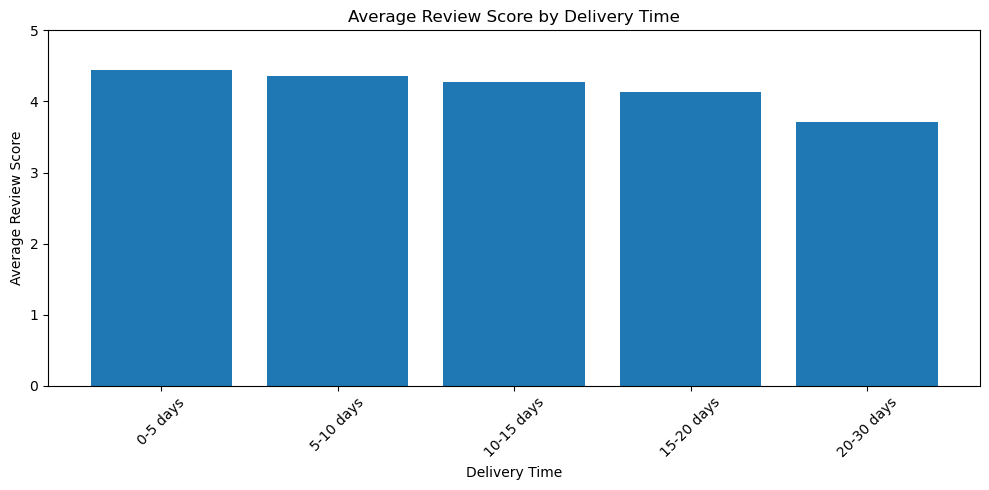

In [146]:
plt.figure(figsize=(10, 5))

plt.bar(
    delivery_review_summary.index.astype(str),
    delivery_review_summary["avg_review"]
)

plt.title("Average Review Score by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Average Review Score")

plt.xticks(rotation=45)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

## Observation : 

Customer satisfaction decreases as delivery time increases.

Orders delivered quickly receive stronger average reviews, while longer
delivery periods are associated with lower customer ratings.

# 15. Late vs On-Time Deliveries 

In [154]:
late_summary = (
    delivered_orders
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        avg_review=("review_score", "mean")
    )
)

late_summary.round(2)

,orders,avg_review
delivery_status,,
Late,7826,2.57
On Time,88644,4.29


In [156]:
late_percentage = (
    delivered_orders["was_late"]
    .mean() * 100
)

print(
    f"Late deliveries: "
    f"{late_percentage:.2f}%"
)

Late deliveries: 8.11%


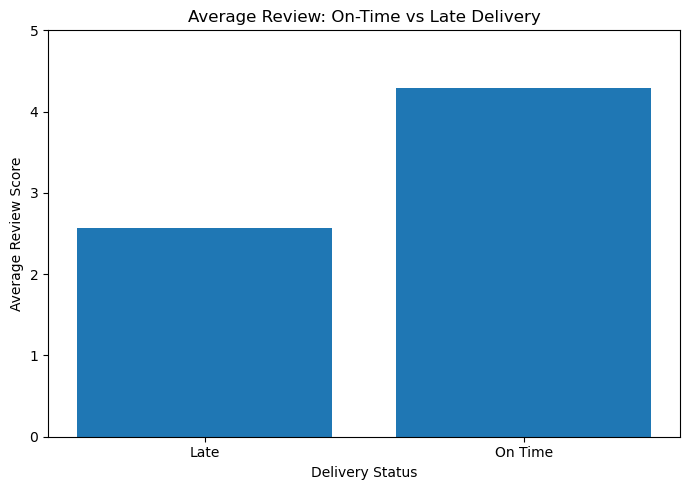

In [158]:
plt.figure(figsize=(7, 5))

plt.bar(
    late_summary.index,
    late_summary["avg_review"]
)

plt.title("Average Review: On-Time vs Late Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

## Observation : 

Delivery reliability shows a clear relationship with customer satisfaction.

On-time orders received an average review of approximately **4.29 stars**,
compared with only **2.57 stars** for late orders.

This is one of the strongest findings in the analysis.

# 16. Statistical Testing 

## Statistical Test: Late vs On-Time Reviews

A Welch's independent-samples t-test is used to test whether the difference
in average customer reviews between on-time and late deliveries is
statistically significant.

**H₀:** Average review scores are the same for on-time and late deliveries.

**H₁:** Average review scores differ between on-time and late deliveries.

In [163]:
on_time_reviews = (
    delivered_orders.loc[
        delivered_orders["was_late"] == False,
        "review_score"
    ]
    .dropna()
)

late_reviews = (
    delivered_orders.loc[
        delivered_orders["was_late"] == True,
        "review_score"
    ]
    .dropna()
)

In [165]:
t_stat, p_value = ttest_ind(
    on_time_reviews,
    late_reviews,
    equal_var=False
)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 89.38
P-value: 0.000000


In [167]:
alpha = 0.05

if p_value < alpha:
    print(
        "Result: Reject the null hypothesis."
    )
    print(
        "There is a statistically significant "
        "difference in review scores between "
        "late and on-time deliveries."
    )
else:
    print(
        "Result: Fail to reject the null hypothesis."
    )

Result: Reject the null hypothesis.
There is a statistically significant difference in review scores between late and on-time deliveries.


### Result

The difference in customer ratings between late and on-time orders is
statistically significant.

Late delivery is therefore strongly associated with lower customer
satisfaction in this dataset.

This result identifies an association and should not be interpreted as proof
that delivery lateness is the only cause of poor reviews.

# 17. Business Insight 



# Key Business Insights

### 1. Delivery reliability is strongly linked to customer satisfaction

On-time orders received an average review of approximately **4.29 stars**,
compared with **2.57 stars** for late deliveries.

### 2. Longer delivery times are associated with lower ratings

Customer ratings generally decline as delivery time increases, with the
largest declines appearing among longer delivery periods.

### 3. Credit cards dominate payment behaviour

Credit cards are the most commonly used payment method by a large margin.

### 4. Most customers purchase relatively small baskets

Single-item orders make up a large proportion of transactions.

### 5. Customer activity follows identifiable time patterns

Order activity changes across months, days of the week and hours of the day,
which may help support operational planning.

# 18. Business Recommendations 



# Recommendations

Based on the analysis, the business should:

- **Prioritise on-time delivery.** Late orders receive substantially lower
  customer ratings.

- **Monitor orders approaching their estimated delivery date.** Early
  intervention may help reduce late deliveries and poor customer experiences.

- **Investigate unusually long delivery times.** These orders may reveal
  operational or logistics problems.

- **Use peak purchasing periods for planning.** Order trends by month, day and
  hour can help guide staffing and operational capacity.

- **Maintain reliable credit-card payment support.** Credit cards account for
  the majority of transactions.

# 19. Limitations 
 
 
 
 
 # Limitations

- The dataset contains order-level information but limited customer demographic
  information.

- `customer_id` is unique for each order in this dataset, so it cannot reliably
  be used for repeat-customer or RFM analysis.

- Customer satisfaction may also be influenced by factors not included in the
  data, such as product quality, seller performance and customer service.

- Statistical relationships show association rather than causation.

- Some extreme delivery times may represent genuine service problems or data
  quality issues and should be interpreted carefully.

# 20. Conclusion 

# Conclusion

This project analysed e-commerce order data to understand purchasing patterns,
payment behaviour, delivery performance and customer satisfaction.

The strongest finding was the relationship between delivery reliability and
customer reviews. On-time orders averaged approximately **4.29 stars**, while
late orders averaged only **2.57 stars**. Customer ratings also declined as
delivery times became longer.

Credit cards were the dominant payment method, while customer activity showed
clear patterns across time.

Overall, the results suggest that improving delivery reliability should be a
key operational priority for improving the customer experience.

This concludes Part 1 of the project. Part 2 will build on these findings by
exploring whether machine-learning models can identify orders at risk of a
poor customer experience.

# 21. Save Cleaned Data 

In [185]:
df.to_csv(
    "customer_orders_cleaned.csv",
    index=False
)

delivered_orders.to_csv(
    "delivered_orders_cleaned.csv",
    index=False
)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.
